Ingrese el nombre del archivo de imagen (incluyendo la extensión): /content/Cuadrado.jpg


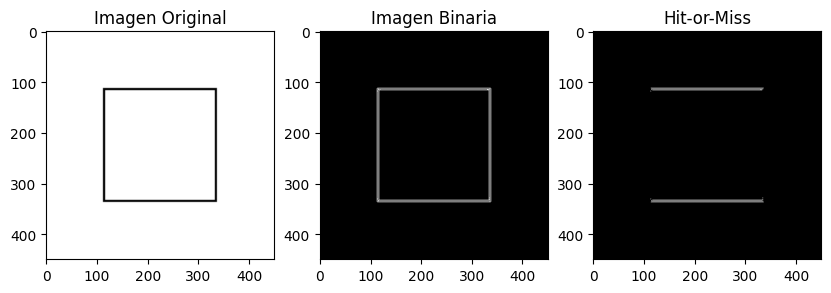

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import io
import skimage.color as color

# Función para cargar la imagen y aplicar Hit-or-Miss
def cargarImagen():
    filename = input("Ingrese el nombre del archivo de imagen (incluyendo la extensión): ")

    # Leer la imagen
    img = io.imread(filename)

    # Mostrar la imagen original
    plt.figure(figsize=(10, 7))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Imagen Original')

    # Convertir la imagen a escala de grises si es necesario
    if img.ndim == 3:
        img_gray = color.rgb2gray(img)
    else:
        img_gray = img

    # Binarizar la imagen
    _, img_binaria = cv2.threshold((img_gray * 255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Mostrar la imagen binaria
    plt.subplot(1, 3, 2)
    plt.imshow(img_binaria, cmap='gray')
    plt.title('Imagen Binaria')

    # Definir los elementos estructurantes para el Hit-or-Miss
    se1 = np.array([[0, 0, 0], [1, 1, 0], [0, 0, 0]], dtype=np.uint8)
    se2 = np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1]], dtype=np.uint8)

    # Aplicar la operación Hit-or-Miss
    hit_miss = cv2.morphologyEx(img_binaria, cv2.MORPH_HITMISS, se1 - se2)

    # Mostrar la imagen resultante de Hit-or-Miss
    plt.subplot(1, 3, 3)
    plt.imshow(hit_miss, cmap='gray')
    plt.title('Hit-or-Miss')

    # Mostrar todas las imágenes
    plt.show()

# Llamar a la función para cargar la imagen
cargarImagen()
